# **Trader Behavior Analysis Based on Bitcoin Fear & Greed Index**

## 1. IMPORT LIBRARIES
## =========================

In [2]:
!pip install matplotlib seaborn pandas numpy scipy


[notice] A new release of pip is available: 24.3.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import ttest_ind

import warnings
warnings.filterwarnings('ignore')

In [4]:
# Visualization style
sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (12,6)

print("Libraries Imported Successfully")


Libraries Imported Successfully


## 2. LOAD DATASETS
## =========================

In [6]:
fear_df = pd.read_csv("fear_greed_index.csv")

trades_df = pd.read_csv("historical_data.csv")

print("Datasets Loaded Successfully")


Datasets Loaded Successfully


## 3. UNDERSTAND DATASETS
## ============================================================

In [ ]:
print("\n================ FEAR & GREED DATA =================")
print(fear_df.head())

print("\nFear & Greed Columns")
print(fear_df.columns)

print("\nFear & Greed Info")
print(fear_df.info())




================ FEAR & GREED DATA =================
    timestamp  value classification        date
0  1517463000     30           Fear  2018-02-01
1  1517549400     15   Extreme Fear  2018-02-02
2  1517635800     40           Fear  2018-02-03
3  1517722200     24   Extreme Fear  2018-02-04
4  1517808600     11   Extreme Fear  2018-02-05

Fear & Greed Columns
Index(['timestamp', 'value', 'classification', 'date'], dtype='object')

Fear & Greed Info
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2644 entries, 0 to 2643
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   timestamp       2644 non-null   int64 
 1   value           2644 non-null   int64 
 2   classification  2644 non-null   object
 3   date            2644 non-null   object
dtypes: int64(2), object(2)
memory usage: 82.8+ KB
None


In [8]:
print("\n================ TRADING DATA =================")
print(trades_df.head())

print("\nTrading Data Columns")
print(trades_df.columns)

print("\nTrading Data Info")
print(trades_df.info())


================ TRADING DATA =================
                                      Account  Coin  Execution Price  \
0  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9769   
1  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9800   
2  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9855   
3  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9874   
4  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9894   

   Size Tokens  Size USD Side     Timestamp IST  Start Position Direction  \
0       986.87   7872.16  BUY  02-12-2024 22:50        0.000000       Buy   
1        16.00    127.68  BUY  02-12-2024 22:50      986.524596       Buy   
2       144.09   1150.63  BUY  02-12-2024 22:50     1002.518996       Buy   
3       142.98   1142.04  BUY  02-12-2024 22:50     1146.558564       Buy   
4         8.73     69.75  BUY  02-12-2024 22:50     1289.488521       Buy   

   Closed PnL                                   Transac

## 4. DATA CLEANING
## =========================

In [10]:
# Convert Date Columns
# ---------------------------

fear_df['date'] = pd.to_datetime(fear_df['date'])

trades_df['Timestamp IST'] = pd.to_datetime(
    trades_df['Timestamp IST'],
    dayfirst=True
)


In [11]:
# Create Common Date Column
# ---------------------------

fear_df['Date'] = fear_df['date'].dt.date

trades_df['Date'] = trades_df['Timestamp IST'].dt.date

In [12]:
# Check Missing Values
# ---------------------------

print("\nFear Dataset Missing Values")
print(fear_df.isnull().sum())

print("\nTrades Dataset Missing Values")
print(trades_df.isnull().sum())


Fear Dataset Missing Values
timestamp         0
value             0
classification    0
date              0
Date              0
dtype: int64

Trades Dataset Missing Values
Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
Timestamp IST       0
Start Position      0
Direction           0
Closed PnL          0
Transaction Hash    0
Order ID            0
Crossed             0
Fee                 0
Trade ID            0
Timestamp           0
Date                0
dtype: int64


In [13]:
# Remove Duplicates
# ---------------------------

fear_df.drop_duplicates(inplace=True)

trades_df.drop_duplicates(inplace=True)

print("\nDuplicates Removed Successfully")



Duplicates Removed Successfully


In [14]:
# MERGE BOTH DATASETS
# ============================================================

merged_df = pd.merge(
    trades_df,
    fear_df,
    on='Date',
    how='left'
)

print("\nMerged Dataset Shape:", merged_df.shape)
print("\nMerged Dataset Preview")



Merged Dataset Shape: (211224, 21)

Merged Dataset Preview


In [15]:
print(merged_df.head())

                                      Account  Coin  Execution Price  \
0  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9769   
1  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9800   
2  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9855   
3  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9874   
4  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9894   

   Size Tokens  Size USD Side       Timestamp IST  Start Position Direction  \
0       986.87   7872.16  BUY 2024-12-02 22:50:00        0.000000       Buy   
1        16.00    127.68  BUY 2024-12-02 22:50:00      986.524596       Buy   
2       144.09   1150.63  BUY 2024-12-02 22:50:00     1002.518996       Buy   
3       142.98   1142.04  BUY 2024-12-02 22:50:00     1146.558564       Buy   
4         8.73     69.75  BUY 2024-12-02 22:50:00     1289.488521       Buy   

   Closed PnL  ...     Order ID  Crossed       Fee      Trade ID  \
0         0.0  ...  5201

## 6. FEATURE ENGINEERING
## ============================================================

In [17]:
# Profit or Loss Flag
# ---------------------------

merged_df['is_profit'] = merged_df['Closed PnL'] > 0

# ---------------------------
# Absolute PnL
# ---------------------------

merged_df['abs_pnl'] = merged_df['Closed PnL'].abs()

# ---------------------------
# Trade Volume
# ---------------------------

merged_df['trade_volume'] = (
    merged_df['Execution Price'] *
    merged_df['Size Tokens']
)
# Trade Hour
# ---------------------------

merged_df['trade_hour'] = (
    merged_df['Timestamp IST'].dt.hour
)

print("\nFeature Engineering Completed")


Feature Engineering Completed


## BASIC STATISTICS
## ============================================================

In [ ]:
print("\n================ SUMMARY STATISTICS =================")

print(
    merged_df[
        [
            'Execution Price',
            'Size Tokens',
            'Size USD',
            'Closed PnL',
            'Fee'
        ]
    ].describe()
)


================ SUMMARY STATISTICS =================
       Execution Price   Size Tokens      Size USD     Closed PnL  \
count    211224.000000  2.112240e+05  2.112240e+05  211224.000000   
mean      11414.723350  4.623365e+03  5.639451e+03      48.749001   
std       29447.654868  1.042729e+05  3.657514e+04     919.164828   
min           0.000005  8.740000e-07  0.000000e+00 -117990.104100   
25%           4.854700  2.940000e+00  1.937900e+02       0.000000   
50%          18.280000  3.200000e+01  5.970450e+02       0.000000   
75%         101.580000  1.879025e+02  2.058960e+03       5.792797   
max      109004.000000  1.582244e+07  3.921431e+06  135329.090100   

                 Fee  
count  211224.000000  
mean        1.163967  
std         6.758854  
min        -1.175712  
25%         0.016121  
50%         0.089578  
75%         0.393811  
max       837.471593  



================ SENTIMENT DISTRIBUTION =================
classification
Fear             61837
Greed            50303
Extreme Greed    39992
Neutral          37686
Extreme Fear     21400
Name: count, dtype: int64


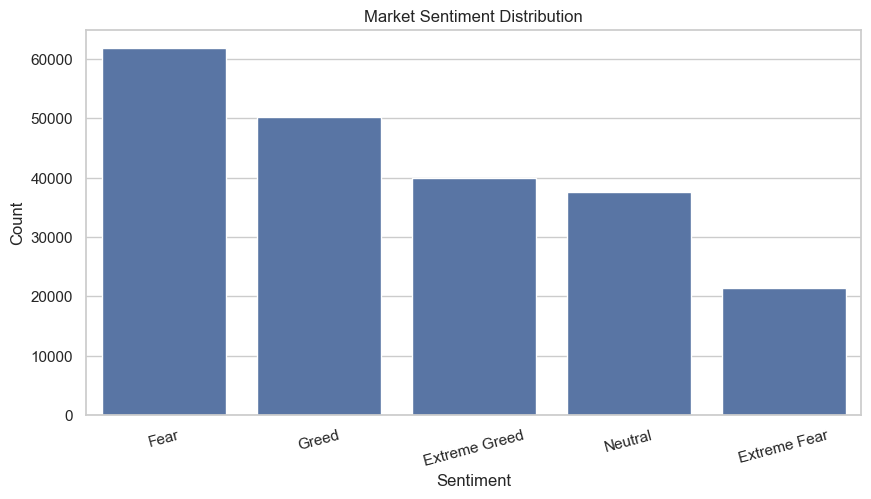

In [19]:
# FEAR vs GREED DISTRIBUTION
# ============================================================

print("\n================ SENTIMENT DISTRIBUTION =================")

print(
    merged_df['classification'].value_counts()
)

plt.figure(figsize=(10,5))

sns.countplot(
    x='classification',
    data=merged_df,
    order=merged_df['classification'].value_counts().index
)

plt.title("Market Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Count")
plt.xticks(rotation=15)
plt.show()


================ AVERAGE PnL BY SENTIMENT =================
classification
Extreme Greed    67.892861
Fear             54.290400
Greed            42.743559
Extreme Fear     34.537862
Neutral          34.307718
Name: Closed PnL, dtype: float64


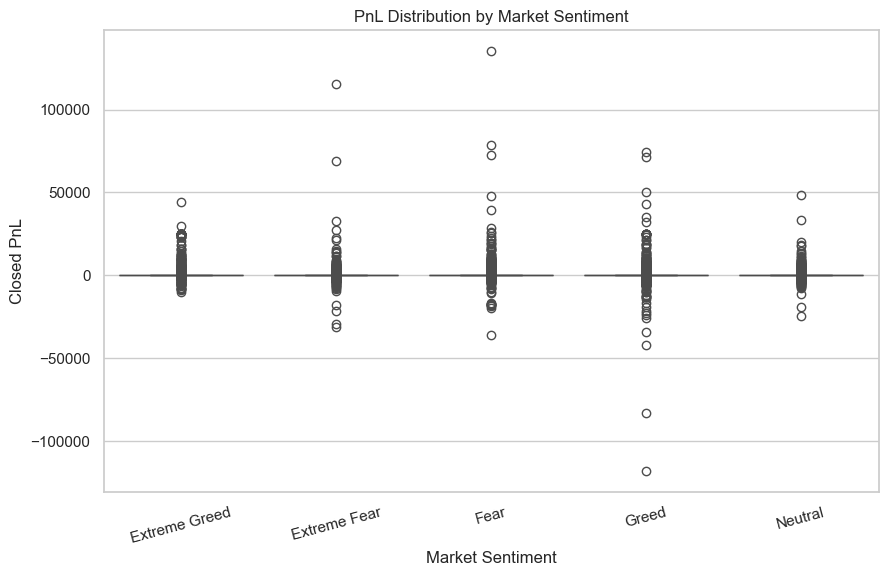

In [20]:
# AVERAGE PnL BY SENTIMENT
# ============================================================

avg_pnl = merged_df.groupby(
    'classification'
)['Closed PnL'].mean().sort_values(ascending=False)

print("\n================ AVERAGE PnL BY SENTIMENT =================")

print(avg_pnl)

plt.figure(figsize=(10,6))

sns.boxplot(
    x='classification',
    y='Closed PnL',
    data=merged_df
)

plt.title("PnL Distribution by Market Sentiment")
plt.xlabel("Market Sentiment")
plt.ylabel("Closed PnL")
plt.xticks(rotation=15)
plt.show()


================ WIN RATE (%) =================
classification
Extreme Fear     37.060748
Extreme Greed    46.494299
Fear             42.076750
Greed            38.482794
Neutral          39.699093
Name: is_profit, dtype: float64


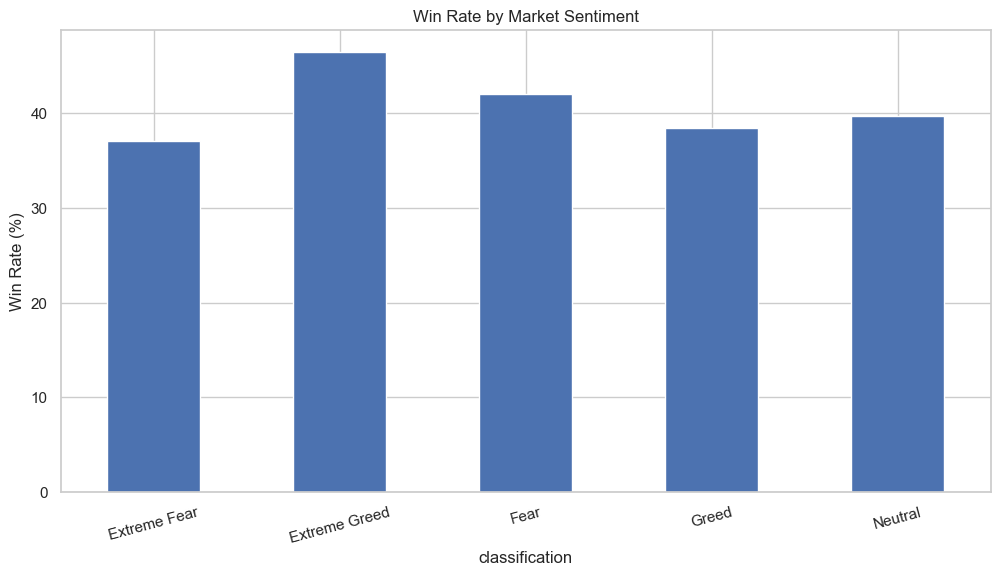

In [21]:
# WIN RATE ANALYSIS
# ============================================================

win_rate = merged_df.groupby(
    'classification'
)['is_profit'].mean() * 100

print("\n================ WIN RATE (%) =================")

print(win_rate)

win_rate.plot(kind='bar')

plt.title("Win Rate by Market Sentiment")
plt.ylabel("Win Rate (%)")
plt.xticks(rotation=15)
plt.show()


================ BUY vs SELL ANALYSIS =================
classification  Side
Extreme Fear    BUY      34.114627
                SELL     34.980106
Extreme Greed   BUY      10.498927
                SELL    114.584643
Fear            BUY      63.927104
                SELL     45.049641
Greed           BUY      25.002302
                SELL     59.691091
Neutral         BUY      29.227429
                SELL     39.456408
Name: Closed PnL, dtype: float64


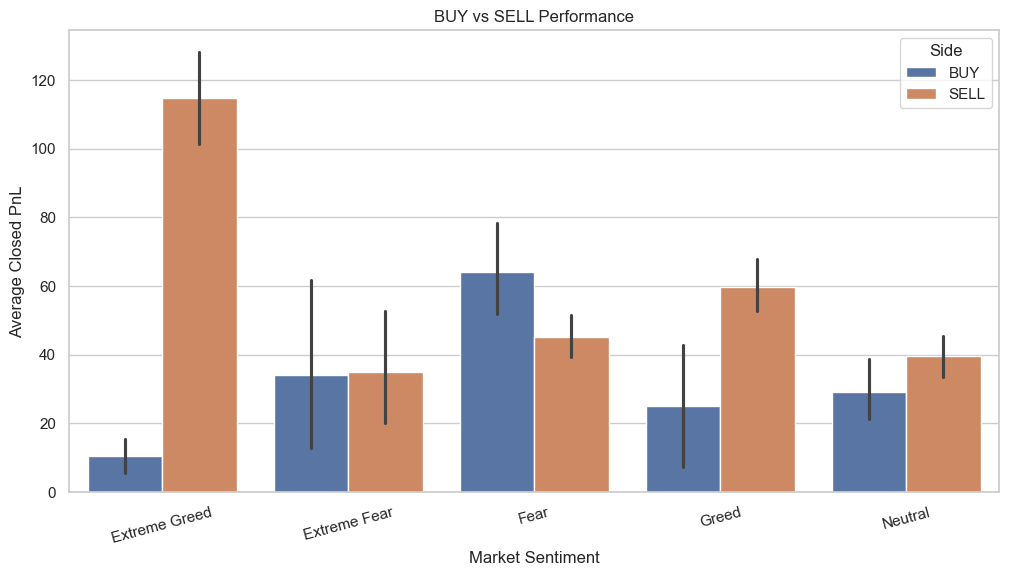

In [22]:
#  BUY vs SELL ANALYSIS
# ============================================================

side_analysis = merged_df.groupby(
    ['classification', 'Side']
)['Closed PnL'].mean()

print("\n================ BUY vs SELL ANALYSIS =================")

print(side_analysis)

plt.figure(figsize=(12,6))

sns.barplot(
    x='classification',
    y='Closed PnL',
    hue='Side',
    data=merged_df
)
plt.title("BUY vs SELL Performance")
plt.xlabel("Market Sentiment")
plt.ylabel("Average Closed PnL")
plt.xticks(rotation=15)
plt.show()

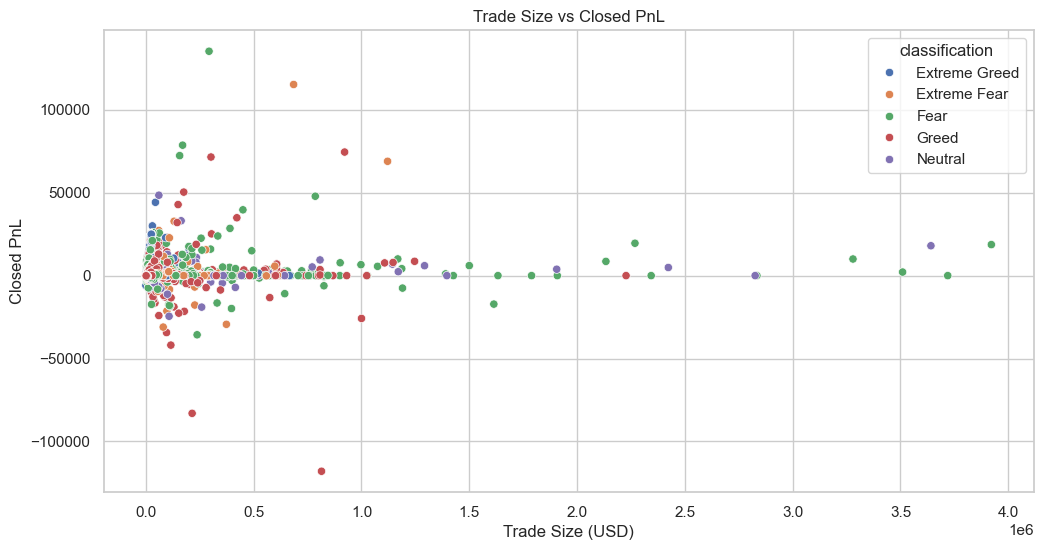

In [23]:
# TRADE SIZE vs PROFITABILITY
# ============================================================

plt.figure(figsize=(12,6))

sns.scatterplot(
    x='Size USD',
    y='Closed PnL',
    hue='classification',
    data=merged_df
)

plt.title("Trade Size vs Closed PnL")
plt.xlabel("Trade Size (USD)")
plt.ylabel("Closed PnL")
plt.show()


================ MOST ACTIVE HOURS =================
trade_hour
0      9856
1     10481
2      8181
3     10524
4     10015
5      9538
6      9057
7      8585
8      7848
9      6548
10     6745
11     6150
12     6950
13     8301
14     6840
15     7301
16     5865
17     6299
18     9641
19    12628
20    12731
21    11022
22    10096
23    10022
dtype: int64


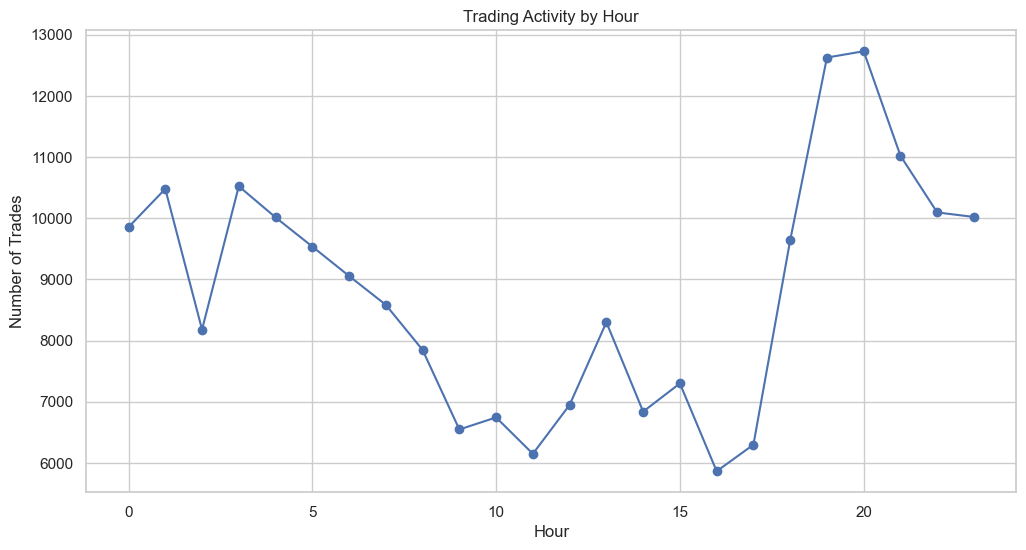

In [24]:
# MOST ACTIVE TRADING HOURS
# ============================================================

hourly_trades = merged_df.groupby(
    'trade_hour'
).size()

print("\n================ MOST ACTIVE HOURS =================")

print(hourly_trades)

hourly_trades.plot(
    kind='line',
    marker='o'
)

plt.title("Trading Activity by Hour")
plt.xlabel("Hour")
plt.ylabel("Number of Trades")
plt.show()


================ HOURLY PROFITABILITY =================
trade_hour
0      43.126269
1      49.918770
2      34.205399
3      43.711571
4      48.663764
5      40.460611
6      32.983412
7      83.026712
8      58.886420
9      44.979426
10     61.347489
11     76.863003
12    131.173707
13     52.382349
14     23.124431
15     58.562155
16     41.975938
17     34.481087
18     44.993427
19     55.861869
20     49.711340
21     31.169804
22     37.808613
23     18.753063
Name: Closed PnL, dtype: float64


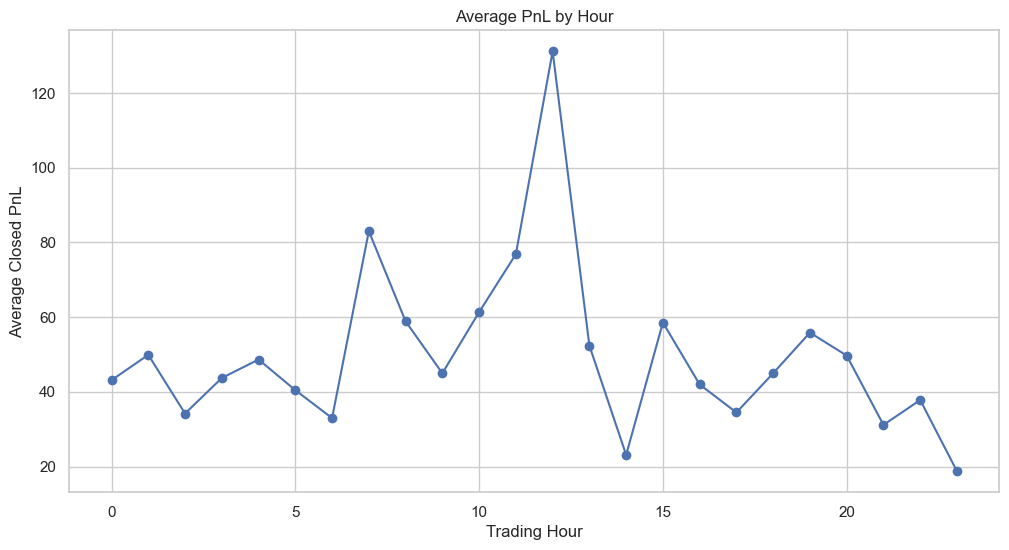

In [25]:
# PROFITABILITY BY HOUR
# ============================================================

hourly_pnl = merged_df.groupby(
    'trade_hour'
)['Closed PnL'].mean()

print("\n================ HOURLY PROFITABILITY =================")

print(hourly_pnl)

hourly_pnl.plot(
    kind='line',
    marker='o'
)

plt.title("Average PnL by Hour")
plt.xlabel("Trading Hour")
plt.ylabel("Average Closed PnL")
plt.show()


================ TOP 10 TRADERS =================
Account
0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23    2.143383e+06
0x083384f897ee0f19899168e3b1bec365f52a9012    1.600230e+06
0xbaaaf6571ab7d571043ff1e313a9609a10637864    9.401638e+05
0x513b8629fe877bb581bf244e326a047b249c4ff1    8.404226e+05
0xbee1707d6b44d4d52bfe19e41f8a828645437aab    8.360806e+05
0x4acb90e786d897ecffb614dc822eb231b4ffb9f4    6.777471e+05
0x72743ae2822edd658c0c50608fd7c5c501b2afbd    4.293556e+05
0x430f09841d65beb3f27765503d0f850b8bce7713    4.165419e+05
0x72c6a4624e1dffa724e6d00d64ceae698af892a0    4.030115e+05
0x75f7eeb85dc639d5e99c78f95393aa9a5f1170d4    3.790954e+05
Name: Closed PnL, dtype: float64


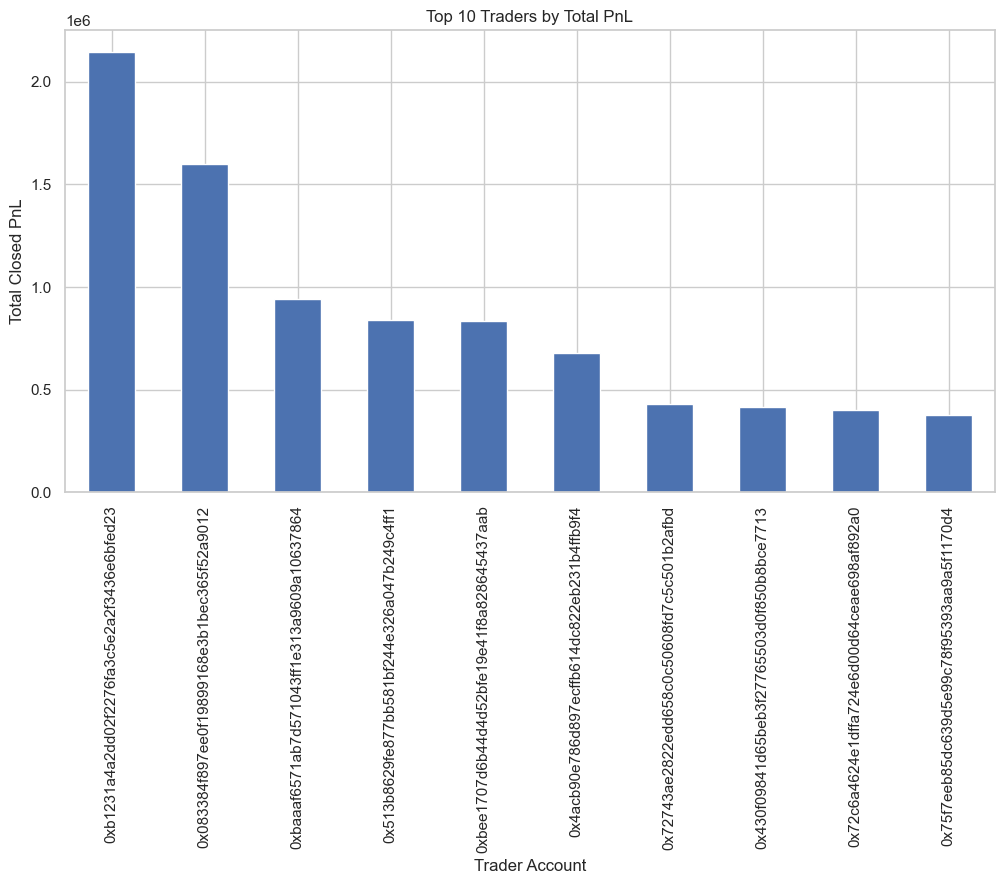

In [26]:
# TOP 10 TRADERS
# ============================================================

top_traders = merged_df.groupby(
    'Account'
)['Closed PnL'].sum().sort_values(
    ascending=False
).head(10)

print("\n================ TOP 10 TRADERS =================")

print(top_traders)

top_traders.plot(kind='bar')

plt.title("Top 10 Traders by Total PnL")
plt.xlabel("Trader Account")
plt.ylabel("Total Closed PnL")
plt.show()


================ AVERAGE FEES =================
classification
Extreme Fear     1.116291
Extreme Greed    0.675902
Fear             1.495172
Greed            1.254372
Neutral          1.044798
Name: Fee, dtype: float64


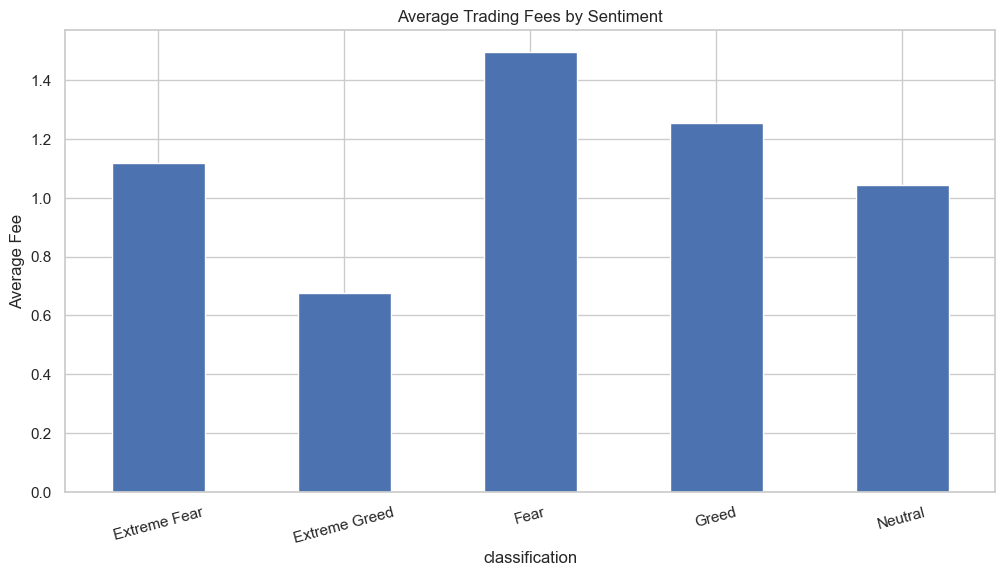

In [27]:
# FEES ANALYSIS
# ============================================================

fee_analysis = merged_df.groupby(
    'classification'
)['Fee'].mean()

print("\n================ AVERAGE FEES =================")

print(fee_analysis)

fee_analysis.plot(kind='bar')

plt.title("Average Trading Fees by Sentiment")
plt.ylabel("Average Fee")
plt.xticks(rotation=15)
plt.show()

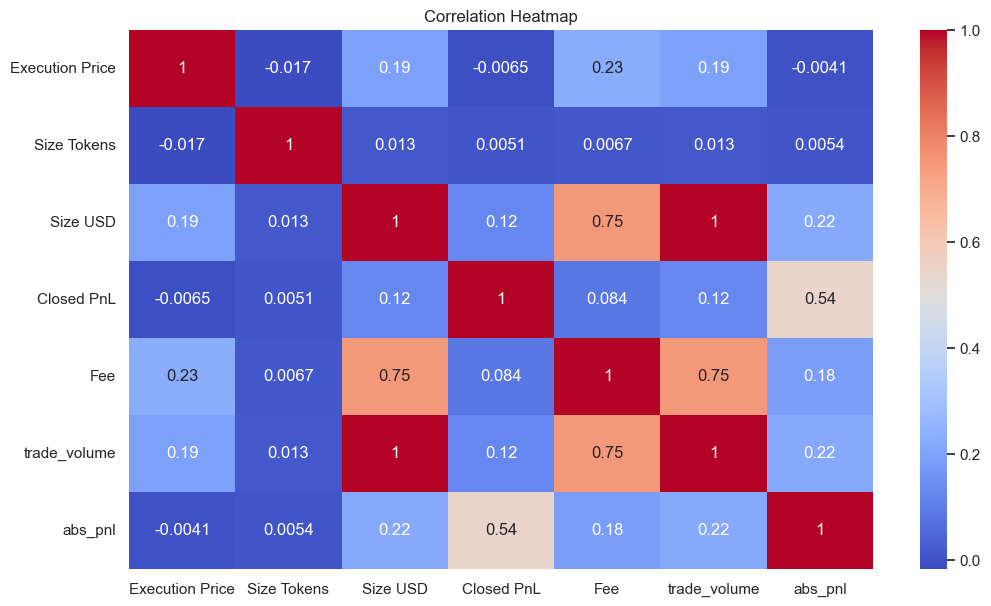

In [28]:
# CORRELATION HEATMAP
# ============================================================

numeric_cols = [
    'Execution Price',
    'Size Tokens',
    'Size USD',
    'Closed PnL',
    'Fee',
    'trade_volume',
    'abs_pnl'
]

corr_matrix = merged_df[numeric_cols].corr()

plt.figure(figsize=(12,7))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")
plt.show()


================ PROFIT vs LOSS =================
is_profit       False  True 
classification              
Extreme Fear    13469   7931
Extreme Greed   21398  18594
Fear            35818  26019
Greed           30945  19358
Neutral         22725  14961


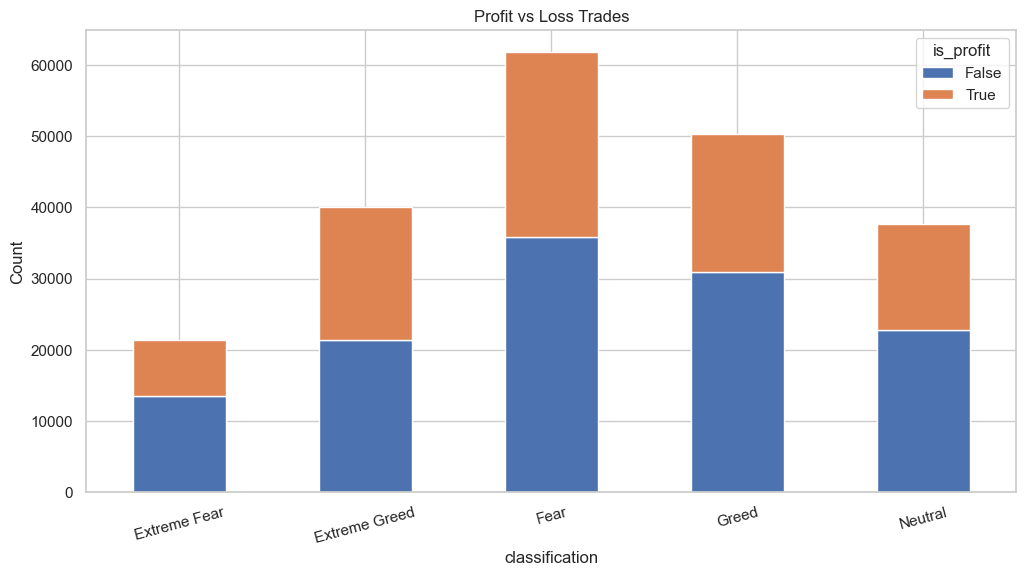

In [29]:
# PROFITABLE vs LOSS TRADES
# ============================================================

profit_loss = merged_df.groupby(
    ['classification', 'is_profit']
).size().unstack()

print("\n================ PROFIT vs LOSS =================")

print(profit_loss)

profit_loss.plot(
    kind='bar',
    stacked=True
)

plt.title("Profit vs Loss Trades")
plt.ylabel("Count")
plt.xticks(rotation=15)
plt.show()

In [30]:
#  T-TEST (STATISTICAL TESTING)
# ============================================================

fear_pnl = merged_df[
    merged_df['classification'].isin(
        ['Fear', 'Extreme Fear']
    )
]['Closed PnL']

greed_pnl = merged_df[
    merged_df['classification'].isin(
        ['Greed', 'Extreme Greed']
    )
]['Closed PnL']

t_stat, p_value = ttest_ind(
    fear_pnl,
    greed_pnl,
    nan_policy='omit'
)

print("\n================ T-TEST RESULTS =================")

print("T-Statistic :", t_stat)

print("P-Value :", p_value)

if p_value < 0.05:
    print("\nSignificant difference exists between Fear and Greed trading performance")

else:
    print("\nNo statistically significant difference found")


================ T-TEST RESULTS =================
T-Statistic : -0.9880761998461425
P-Value : 0.3231167085211579

No statistically significant difference found


## KEY INSIGHTS
## ============================================================

In [ ]:
print("\n===================================================")
print("FINAL INSIGHTS")
print("===================================================")


FINAL INSIGHTS


In [32]:
# Best Sentiment
# ---------------------------

best_sentiment = avg_pnl.idxmax()

print(f"\n1. Highest profitability observed during: {best_sentiment}")


1. Highest profitability observed during: Extreme Greed


In [33]:
# Best Trading Hour
# ---------------------------

best_hour = hourly_pnl.idxmax()

print(f"\n2. Most profitable trading hour: {best_hour}:00")


2. Most profitable trading hour: 12:00


In [34]:
# Best Trader
# ---------------------------

best_trader = top_traders.idxmax()

print(f"\n3. Top performing trader account:\n{best_trader}")



3. Top performing trader account:
0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23


In [35]:
# Win Rate
# ---------------------------

print("\n4. Win Rate by Sentiment")
print(win_rate)


4. Win Rate by Sentiment
classification
Extreme Fear     37.060748
Extreme Greed    46.494299
Fear             42.076750
Greed            38.482794
Neutral          39.699093
Name: is_profit, dtype: float64


In [36]:
# Trade Activity
# ---------------------------

most_active_hour = hourly_trades.idxmax()

print(f"\n5. Highest trading activity observed at: {most_active_hour}:00")



5. Highest trading activity observed at: 20:00


In [ ]:
# EXPORT FINAL DATASET
# ============================================================

merged_df.to_csv(
    "final_merged_analysis.csv",
    index=False
)

print("\nFinal Dataset Exported Successfully")



Final Dataset Exported Successfully


# ============================================================
# END OF PROJECT
# ============================================================